In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import json, gc, sys, pickle
from pathlib import Path
from typing import Dict, Tuple

import torch
from torch_geometric.data import HeteroData

/home/biffon/.conda/envs/phage_host_env_gnn_model/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# DIRS & CONFIGS (modify the directories accordingly)
TRAINED_MODELS_DIR = Path("PH_trained_models")
CV_RESULTS_DIR = Path("PH_q_LOGOCV_results")
PAIR_ASSIGNMENT = Path("both_unseen_assignment_results")
INFERENCE_OUT_DIR = Path("inference_n_inVitro_benchmark/both_unseen_inference_predictions_NEW1")
FIG_DIR = INFERENCE_OUT_DIR / "figures"
INFERENCE_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ASSIGNMENT_CSV = (PAIR_ASSIGNMENT / "both_unseen_pair_assignment_min_quantile.csv")

K_PHAGE_PHAGE = 10
K_HOST_HOST = 10
MODEL_NAMES = ["ESM2", "ESMC", "LucaOne", "BacFormer", "AF3"]
PHAGE_MP = ("phage", "similar_to", "phage")
HOST_MP = ("host", "similar_to", "host")

In [4]:
# Loading both-unseen host-phage quantile assignments

pair_assignment = pd.read_csv(ASSIGNMENT_CSV)
pair_assignment["host_quantile"] = (pair_assignment["host_quantile"].astype(float))
pair_assignment["phage_quantile"] = (pair_assignment["phage_quantile"].astype(float))
pair_assignment["pair_quantile_min"] = (pair_assignment["pair_quantile_min"].astype(float))

display(pair_assignment.head())
print("Total candidate pairs:", len(pair_assignment))
print("Models:", pair_assignment["model"].unique())

,model,host,phage,host_quantile,phage_quantile,pair_quantile_min,host_support_status,phage_support_status,pair_support_status
0,ESM2,Kpcas091,A1a,0.9,0.85,0.85,supported,supported,supported
1,ESM2,Kpcas091,A1b,0.9,0.85,0.85,supported,supported,supported
2,ESM2,Kpcas091,A1c,0.9,0.85,0.85,supported,supported,supported
3,ESM2,Kpcas091,A1d,0.9,0.80,0.80,supported,supported,supported
4,ESM2,Kpcas091,A1e,0.9,0.85,0.85,supported,supported,supported


Total candidate pairs: 24782
Models: ['ESM2' 'ESMC' 'LucaOne' 'BacFormer' 'AF3']


In [5]:
# extracting both-unseen LOGOCV performance (AUPRC-based routing)
cv_results = []
for model in pair_assignment["model"].unique():
    model_dir = CV_RESULTS_DIR / f"{model}_results_raw"
    for q in sorted(pair_assignment["pair_quantile_min"].unique()):
        pickle_file = (model_dir / f"logocv_both_unseen_results_{model}_q_{q:.3f}.pickle")
        if not pickle_file.exists():
            print("Missing:", pickle_file)
            continue

        with open(pickle_file, "rb") as f:
            result = pickle.load(f)

        cv_results.append(
            {
                "model": model,
                "pair_quantile_min": float(q),
                "pooled_auc": float(result["pooled_auc"]),
                "pooled_ap": float(result["pooled_ap"])
            }
        )

cv_results_df = pd.DataFrame(cv_results)
print("Extracted LOGOCV results:", cv_results_df.shape)
display(cv_results_df.head())

Extracted LOGOCV results: (25, 4)


,model,pair_quantile_min,pooled_auc,pooled_ap
0,ESM2,0.75,0.679904,0.362364
1,ESM2,0.80,0.629695,0.330421
2,ESM2,0.85,0.638447,0.333642
3,ESM2,0.90,0.644286,0.293334
4,ESM2,0.95,0.655025,0.331044


In [6]:
# attaching LOGOCV performance to candidate pair routes

pair_candidates = pair_assignment.merge(cv_results_df, on=["model", "pair_quantile_min"], how="left")
print("Candidate routes:", len(pair_candidates))
print("Missing CV metrics:", pair_candidates["pooled_ap"].isna().sum())
display(pair_candidates.head())

Candidate routes: 24782
Missing CV metrics: 0


,model,host,phage,host_quantile,phage_quantile,pair_quantile_min,host_support_status,phage_support_status,pair_support_status,pooled_auc,pooled_ap
0,ESM2,Kpcas091,A1a,0.9,0.85,0.85,supported,supported,supported,0.638447,0.333642
1,ESM2,Kpcas091,A1b,0.9,0.85,0.85,supported,supported,supported,0.638447,0.333642
2,ESM2,Kpcas091,A1c,0.9,0.85,0.85,supported,supported,supported,0.638447,0.333642
3,ESM2,Kpcas091,A1d,0.9,0.80,0.80,supported,supported,supported,0.629695,0.330421
4,ESM2,Kpcas091,A1e,0.9,0.85,0.85,supported,supported,supported,0.638447,0.333642


In [7]:
# selecting the final route per phage-host pair (Primary metric: AUPRC; Tie breaker: AUC)
final_pair_routing = (
    pair_candidates
    .sort_values(["phage", "host", "pooled_ap", "pooled_auc"],ascending=[True, True, False, False])
    .drop_duplicates(["phage", "host"])
    .reset_index(drop=True)
)
final_pair_routing.to_csv(INFERENCE_OUT_DIR / "both_unseen_new_pairs_routing.csv", index=False)
print("Final routed pairs:", len(final_pair_routing))
display(final_pair_routing.head())

Final routed pairs: 6348


,model,host,phage,host_quantile,phage_quantile,pair_quantile_min,host_support_status,phage_support_status,pair_support_status,pooled_auc,pooled_ap
0,AF3,102KP-HG,A1a,0.90,0.85,0.85,supported,supported,supported,0.655683,0.371200
1,ESMC,1210,A1a,0.90,0.85,0.85,supported,supported,supported,0.664567,0.390417
2,ESMC,132,A1a,0.80,0.85,0.80,supported,supported,supported,0.673065,0.375428
3,ESMC,1446,A1a,0.80,0.85,0.80,supported,supported,supported,0.673065,0.375428
4,ESMC,1468,A1a,0.85,0.85,0.85,supported,supported,supported,0.664567,0.390417


In [8]:
# Validateing the final routing
expected_pairs = (pair_assignment[["phage", "host"]].drop_duplicates().shape[0])

print("Expected phage-host pairs:", expected_pairs)
print("Routed phage-host pairs:", len(final_pair_routing))
print("Duplicate pairs:", final_pair_routing.duplicated(["phage", "host"]).sum())
print("Missing AUPRC:", final_pair_routing["pooled_ap"].isna().sum())

Expected phage-host pairs: 6348
Routed phage-host pairs: 6348
Duplicate pairs: 0
Missing AUPRC: 0


In [9]:
# Summarizing the selected model and quantile routes
route_summary = (final_pair_routing.groupby(["model", "pair_quantile_min"]).size().reset_index(name="n_pairs"))
display(route_summary)
route_summary.to_csv(INFERENCE_OUT_DIR / "both_unseen_final_route_summary.csv", index=False)

,model,pair_quantile_min,n_pairs
0,AF3,0.75,225
1,AF3,0.85,168
2,AF3,0.90,393
3,AF3,0.95,111
4,BacFormer,0.80,258
5,BacFormer,0.90,40
6,ESM2,0.75,17
7,ESM2,0.80,231
8,ESM2,0.85,52
9,ESM2,0.90,1


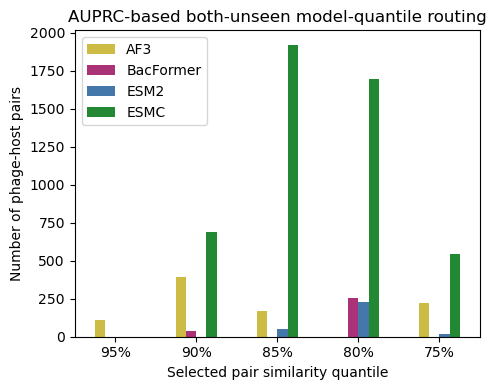

In [10]:
import matplotlib.pyplot as plt

# Visualizing final model-quantile routing
COLORS = {
    "ESMC": "#228833",
    "ESM2": "#4477AA",
    "LucaOne": "#EE6677",
    "AF3": "#CCBB44",
    "BacFormer": "#AA3377",
}

plot_df = (
    route_summary
    .pivot(index="pair_quantile_min", columns="model", values="n_pairs")
    .fillna(0)
    .sort_index(ascending=False)
)

fig, ax = plt.subplots(figsize=(5.0, 4.0))
plot_df.plot(kind="bar", ax=ax, color=[COLORS[model] for model in plot_df.columns])
ax.set_xlabel("Selected pair similarity quantile")
ax.set_ylabel("Number of phage-host pairs")
ax.set_title("AUPRC-based both-unseen model-quantile routing")
ax.set_xticklabels([f"{q * 100:g}%" for q in plot_df.index], rotation=0)
plt.xticks(rotation=0)
ax.legend(frameon=True, title=None)
plt.tight_layout()

plt.savefig(FIG_DIR / "both_unseen_AUPRC_based_model_quantile_routing.png", dpi=500, bbox_inches="tight")
fig.savefig(FIG_DIR / "both_unseen_AUPRC_based_model_quantile_routing.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)
plt.show()

In [ ]:
# Embedding file paths for the respective training and and new phage and host entities
# (Modify file paths acordingly)
TRAIN_PHAGE_DIR = Path("training_embeddings/training_phage_embeddings")
TRAIN_HOST_DIR = Path("training_embeddings/training_host_embeddings")
IN_VITRO_DATA_DIR = Path("inVitro_data_Beamud2023/138Strains_46Phages_embeddings")

EMBEDDING_PATHS = {
    "ESMC":{
        "train_phage":TRAIN_PHAGE_DIR/"phage_rbp_esmc_colmean_embeddings.csv",
        "new_phage":IN_VITRO_DATA_DIR/"ESMC/ESMC_Meamud2023_filtered_phage_embeddings.csv",
        "train_host":TRAIN_HOST_DIR/"host_klocus_esmc_colmean_embeddings.csv",
        "new_host":IN_VITRO_DATA_DIR/"ESMC/ESMC_Meamud2023_filtered_host_embeddings.csv"
        },
    "ESM2":{
        "train_phage":TRAIN_PHAGE_DIR/"phage_rbp_esm2_colmean_embeddings.csv",
        "new_phage":IN_VITRO_DATA_DIR/"ESM2/ESM2_Meamud2023_filtered_phage_embeddings.csv",
        "train_host":TRAIN_HOST_DIR/"host_klocus_esm2_colmean_embeddings.csv",
        "new_host":IN_VITRO_DATA_DIR/"ESM2/ESM2_Meamud2023_filtered_host_embeddings.csv"
        },
    "BacFormer":{
        "train_phage":TRAIN_PHAGE_DIR/"RBPbase_colWmean_bacformer_embeddings.csv",
        "new_phage":IN_VITRO_DATA_DIR/"BacFormer/BacFormer_Meamud2023_filtered_phage_embeddings.csv",
        "train_host":TRAIN_HOST_DIR/"Locibase_colWmean_bacformer_embeddings.csv",
        "new_host":IN_VITRO_DATA_DIR/"BacFormer/BacFormer_Meamud2023_filtered_host_embeddings.csv"
        },
    "AF3":{
        "train_phage":TRAIN_PHAGE_DIR/"PH_esm_if1_rbpbase_af3_structural_embeddings_col_mean.csv",
        "new_phage":IN_VITRO_DATA_DIR/"AF3/AF3_Meamud2023_filtered_phage_embeddings.csv",
        "train_host":TRAIN_HOST_DIR/"PH_esm_if1_locibase_af3_structural_embeddings_col_mean.csv",
        "new_host":IN_VITRO_DATA_DIR/"AF3/AF3_Meamud2023_filtered_host_embeddings.csv"
        },
    "LucaOne":{
        "train_phage":TRAIN_PHAGE_DIR/"phage_rbp_lucaone_colmean_embeddings.csv",
        "new_phage":IN_VITRO_DATA_DIR/"LucaOne/LucaOne_Meamud2023_filtered_phage_embeddings.csv",
        "train_host":TRAIN_HOST_DIR/"host_klocus_lucaone_colmean_embeddings.csv",
        "new_host":IN_VITRO_DATA_DIR/"LucaOne/LucaOne_Meamud2023_filtered_host_embeddings.csv"
        }

}

In [12]:
# Loading embeddings
def load_embeddings(path):
    df = pd.read_csv(path,index_col=0)
    df.index = df.index.astype(str).str.strip()
    df = df.apply(pd.to_numeric,errors="coerce")

    if df.index.duplicated().any():
        raise ValueError(f"Duplicated IDs: {path}")
    return df

embeddings={}
for model in final_pair_routing["model"].unique():
    embeddings[model]={}
    for name,path in EMBEDDING_PATHS[model].items():
        embeddings[model][name]=load_embeddings(path)
        print(model, name, embeddings[model][name].shape)

AF3 train_phage (74, 512)
AF3 new_phage (46, 512)
AF3 train_host (121, 512)
AF3 new_host (138, 512)
ESMC train_phage (74, 1152)
ESMC new_phage (46, 1152)
ESMC train_host (121, 1152)
ESMC new_host (138, 1152)
ESM2 train_phage (74, 1280)
ESM2 new_phage (46, 1280)
ESM2 train_host (121, 1280)
ESM2 new_host (138, 1280)
BacFormer train_phage (74, 480)
BacFormer new_phage (46, 480)
BacFormer train_host (121, 480)
BacFormer new_host (138, 480)


In [13]:
#same-type graph construction helper functions
def build_heterodata(phage_x: torch.Tensor, host_x: torch.Tensor, phage_edges: torch.Tensor, host_edges: torch.Tensor) -> HeteroData:
    data = HeteroData()
    data["phage"].x = phage_x
    data["host"].x = host_x
    data[PHAGE_MP].edge_index = phage_edges
    data[HOST_MP].edge_index = host_edges

    print("\nGraph summary")
    print("Node types:", data.node_types)
    print("Message-passing edge types:", data.edge_types)

    for edge_type in data.edge_types:
        print(f"{edge_type}: {data[edge_type].edge_index.size(1):,} edges")

    return data

def same_type_knn_edges(X: np.ndarray, k: int, source_mask: np.ndarray | None = None, target_mask: np.ndarray | None = None) -> np.ndarray:
    n_nodes = X.shape[0]
    source_mask = (
        np.ones(n_nodes, dtype=bool)
        if source_mask is None
        else np.asarray(source_mask, dtype=bool)
    )

    target_mask = (
        np.ones(n_nodes, dtype=bool)
        if target_mask is None
        else np.asarray(target_mask, dtype=bool)
    )

    if len(source_mask) != n_nodes or len(target_mask) != n_nodes:
        raise ValueError("source_mask and target_mask must match the number of nodes.")

    source_indices = np.flatnonzero(source_mask)
    target_indices = np.flatnonzero(target_mask)

    if len(source_indices) == 0 or len(target_indices) == 0:
        return np.zeros((2, 0), dtype=np.int64)

    X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    similarities = X_norm @ X_norm.T
    np.fill_diagonal(similarities, -np.inf)

    edges = []
    # For each target, select its top-k allowed source neighbours
    for target_idx in target_indices:
        valid_sources = source_indices[source_indices != target_idx]

        if len(valid_sources) == 0:
            continue

        valid_similarities = similarities[target_idx, valid_sources]
        k_use = min(max(1, int(k)), len(valid_sources))

        top_positions = np.argpartition(-valid_similarities, k_use - 1)[:k_use]
        selected_sources = valid_sources[top_positions]

        for source_idx in selected_sources:
            edges.append((int(source_idx), int(target_idx)))

    if not edges:
        return np.zeros((2, 0), dtype=np.int64)

    return np.asarray(edges, dtype=np.int64).T

In [14]:
# loading the training GNN model architecture

sys.path.append("../../a_models")
from GNN_model_inductive import Model
print("Model loaded successfully")

Model loaded successfully


In [15]:
# Resolving trained model files using pair quantile
def resolve_trained_files(model, q):
    model_root = (TRAINED_MODELS_DIR / model / "models_per_q")
    q_dir = (model_root / f"{model}_q_{q:.3f}")

    files = {
        "model": q_dir / f"final_model_{model}_hostq_{q:.3f}_phageq_{q:.3f}.pt",
        "scaler": q_dir / f"final_scalers_{model}_hostq_{q:.3f}_phageq_{q:.3f}.npz",
        "meta": q_dir / f"final_meta_{model}_hostq_{q:.3f}_phageq_{q:.3f}.json"
    }

    for k,v in files.items():
        if not v.exists():
            raise FileNotFoundError(f"Missing {k}: {v}")

    return files

In [16]:
# function for scoring the respective phage-host pairs

@torch.no_grad()
def score_edges(z: Dict[str, torch.Tensor], model, ph_idx, ho_idx) -> np.ndarray:
    dev = z["phage"].device
    ph = torch.as_tensor(ph_idx, device=dev)
    ho = torch.as_tensor(ho_idx, device=dev)
    ei = torch.stack([ph, ho], dim=0)
    logits = model.decode(z, ei)
    return torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32)

In [17]:
# Running inference for one model and pair quantile

def run_route(model_name: str, q: float, pairs: pd.DataFrame) -> pd.DataFrame:
    print(f"\nRunning {model_name}, q={q:.3f}, pairs={len(pairs)}")

    files = resolve_trained_files(model_name, q)
    meta = json.loads(files["meta"].read_text())
    model_kwargs = meta["model_kwargs"]

    with np.load(files["scaler"]) as scaler:
        ph_mean = scaler["ph_mean"].astype(np.float32)
        ph_scale = scaler["ph_scale"].astype(np.float32)
        ho_mean = scaler["ho_mean"].astype(np.float32)
        ho_scale = scaler["ho_scale"].astype(np.float32)

    ph_scale = np.where(ph_scale == 0, 1.0, ph_scale)
    ho_scale = np.where(ho_scale == 0, 1.0, ho_scale)

    emb = embeddings[model_name]

    if emb["train_phage"].shape[1] != emb["new_phage"].shape[1]:
        raise ValueError(f"{model_name}: training-phage and new-phage dimensions do not match.")

    if emb["train_host"].shape[1] != emb["new_host"].shape[1]:
        raise ValueError(f"{model_name}: training-host and new-host dimensions do not match.")

    if emb["train_phage"].shape[1] != len(ph_mean) or emb["new_phage"].shape[1] != len(ph_mean):
        raise ValueError(f"{model_name}: phage embedding dimensions do not match the saved scaler.")

    if emb["train_host"].shape[1] != len(ho_mean) or emb["new_host"].shape[1] != len(ho_mean):
        raise ValueError(f"{model_name}: host embedding dimensions do not match the saved scaler.")

    X_ph_train = ((emb["train_phage"].to_numpy(np.float32) - ph_mean) / ph_scale).astype(np.float32)
    X_ph_new = ((emb["new_phage"].to_numpy(np.float32) - ph_mean) / ph_scale).astype(np.float32)
    X_ho_train = ((emb["train_host"].to_numpy(np.float32) - ho_mean) / ho_scale).astype(np.float32)
    X_ho_new = ((emb["new_host"].to_numpy(np.float32) - ho_mean) / ho_scale).astype(np.float32)

    X_ph_all = np.vstack([X_ph_train, X_ph_new]).astype(np.float32)
    X_ho_all = np.vstack([X_ho_train, X_ho_new]).astype(np.float32)

    n_train_phage = X_ph_train.shape[0]
    n_new_phage = X_ph_new.shape[0]
    n_all_phage = X_ph_all.shape[0]

    n_train_host = X_ho_train.shape[0]
    n_new_host = X_ho_new.shape[0]
    n_all_host = X_ho_all.shape[0]

    print(f"Training phages: {n_train_phage}")
    print(f"New phages: {n_new_phage}")
    print(f"Training hosts: {n_train_host}")
    print(f"New hosts: {n_new_host}")

    # Training nodes can send messages; training and new nodes can receive
    phage_source_mask = np.zeros(n_all_phage, dtype=bool)
    phage_source_mask[:n_train_phage] = True
    phage_target_mask = np.ones(n_all_phage, dtype=bool)

    host_source_mask = np.zeros(n_all_host, dtype=bool)
    host_source_mask[:n_train_host] = True
    host_target_mask = np.ones(n_all_host, dtype=bool)

    phage_edges = same_type_knn_edges(
        X=X_ph_all,
        k=K_PHAGE_PHAGE,
        source_mask=phage_source_mask,
        target_mask=phage_target_mask,
    )

    host_edges = same_type_knn_edges(
        X=X_ho_all,
        k=K_HOST_HOST,
        source_mask=host_source_mask,
        target_mask=host_target_mask,
    )

    # Both-unseen leakage checks
    if phage_edges.shape[1] > 0 and np.any(phage_edges[0] >= n_train_phage):
        raise RuntimeError("New phages appear as message-passing sources.")

    if host_edges.shape[1] > 0 and np.any(host_edges[0] >= n_train_host):
        raise RuntimeError("New hosts appear as message-passing sources.")

    # Verify that every new phage receives exactly top-k training neighbours
    phage_incoming = np.bincount(phage_edges[1], minlength=n_all_phage)[n_train_phage:]
    expected_phage_k = min(K_PHAGE_PHAGE, n_train_phage)
    if not np.all(phage_incoming == expected_phage_k):
        raise RuntimeError(
            f"New-phage incoming-edge counts are incorrect: expected {expected_phage_k}, observed {np.unique(phage_incoming, return_counts=True)}"
        )

    # Verify that every new host receives exactly top-k training neighbours
    host_incoming = np.bincount(host_edges[1], minlength=n_all_host)[n_train_host:]
    expected_host_k = min(K_HOST_HOST, n_train_host)
    if not np.all(host_incoming == expected_host_k):
        raise RuntimeError(
            f"New-host incoming-edge counts are incorrect: expected {expected_host_k}, observed {np.unique(host_incoming, return_counts=True)}"
        )

    print(f"Phage-phage edges: {phage_edges.shape[1]:,}")
    print(f"Host-host edges: {host_edges.shape[1]:,}")
    print("New phages are receive-only:", True)
    print("New hosts are receive-only:", True)

    phage_x = torch.from_numpy(X_ph_all).to(device)
    host_x = torch.from_numpy(X_ho_all).to(device)
    phage_edge_index = torch.from_numpy(phage_edges).long().to(device)
    host_edge_index = torch.from_numpy(host_edges).long().to(device)

    data = build_heterodata(
        phage_x=phage_x,
        host_x=host_x,
        phage_edges=phage_edge_index,
        host_edges=host_edge_index,
    )

    model = Model(data, **model_kwargs).to(device)
    state = torch.load(files["model"], map_location=device)
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        z = model.encode(data)

    new_phage_ids = emb["new_phage"].index.tolist()
    new_host_ids = emb["new_host"].index.tolist()

    phage_to_idx = {
        phage_id: n_train_phage + position
        for position, phage_id in enumerate(new_phage_ids)
    }

    host_to_idx = {
        host_id: n_train_host + position
        for position, host_id in enumerate(new_host_ids)
    }

    missing_phages = sorted(set(pairs["phage"].astype(str)) - set(phage_to_idx))
    missing_hosts = sorted(set(pairs["host"].astype(str)) - set(host_to_idx))

    if missing_phages:
        raise ValueError(f"{model_name}, q={q:.3f}: routed phages missing from new-phage embeddings: {missing_phages}")

    if missing_hosts:
        raise ValueError(f"{model_name}, q={q:.3f}: routed hosts missing from new-host embeddings: {missing_hosts}")

    rows = []

    for pair in pairs.itertuples(index=False):
        phage_idx = phage_to_idx[str(pair.phage)]
        host_idx = host_to_idx[str(pair.host)]
        score = score_edges(z, model, [phage_idx], [host_idx])[0]

        rows.append({
            "phage": str(pair.phage),
            "host": str(pair.host),
            "score": float(score),
            "model": model_name,
            "pair_quantile_min": float(q),
            "host_quantile": float(pair.host_quantile),
            "phage_quantile": float(pair.phage_quantile),
            "cv_auprc": float(pair.pooled_ap),
            "cv_auc": float(pair.pooled_auc),
        })

    del model, data, z, phage_x, host_x, phage_edge_index, host_edge_index
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(rows)

In [18]:
# runningg all routed inference
from tqdm import tqdm
from contextlib import redirect_stdout
import io

prediction_tables, route_logs = [], []
route_groups = list(final_pair_routing.groupby(["model", "pair_quantile_min"]))

for (model_name, q), group in tqdm(route_groups, desc="Running routed inference", unit="route", leave=True):
    buf = io.StringIO()
    with redirect_stdout(buf):
        preds = run_route(model_name, float(q), group)

    prediction_tables.append(preds)
    route_logs.append(buf.getvalue())

pred_df = pd.concat(prediction_tables, ignore_index=True)

print("\n".join(log.rstrip() for log in route_logs))
print("\nRouted inference completed.")
print("Predictions generated:", len(pred_df))

display(pred_df.head())

Running routed inference: 100%|██████████| 14/14 [00:09<00:00,  1.49route/s]


Running AF3, q=0.750, pairs=225
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 138
Phage-phage edges: 1,200
Host-host edges: 2,590
New phages are receive-only: True
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 1,200 edges
('host', 'similar_to', 'host'): 2,590 edges

Running AF3, q=0.850, pairs=168
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 138
Phage-phage edges: 1,200
Host-host edges: 2,590
New phages are receive-only: True
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 1,200 edges
('host', 'similar_to', 'host'): 2,590 edges

Running AF3, q=0.900, pairs=393
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 138
P

,phage,host,score,model,pair_quantile_min,host_quantile,phage_quantile,cv_auprc,cv_auc
0,A3a,102KP-HG,8.288230e-10,AF3,0.75,0.9,0.75,0.364565,0.652357
1,A3a,218KP-HG,5.977535e-10,AF3,0.75,0.9,0.75,0.364565,0.652357
2,A3a,228,5.310332e-04,AF3,0.75,0.9,0.75,0.364565,0.652357
3,A3a,245,5.310332e-04,AF3,0.75,0.9,0.75,0.364565,0.652357
4,A3a,CU371,4.894866e-10,AF3,0.75,0.9,0.75,0.364565,0.652357


In [19]:
# Validating the predicted phage-host pairs
expected_pairs = (final_pair_routing[["phage", "host"]].drop_duplicates().shape[0])
print(f"Expected pairs:, {expected_pairs}; Predicted pairs: {len(pred_df)}; Duplicate pairs: {pred_df.duplicated(['phage', 'host']).sum()}")

if len(pred_df) != expected_pairs:
    raise ValueError("Prediction count does not match expected pairs")

if pred_df.duplicated(["phage", "host"]).any():
    raise ValueError("Duplicate phage-host predictions detected")

print("Validation completed")

Expected pairs:, 6348; Predicted pairs: 6348; Duplicate pairs: 0
Validation completed


In [20]:
# generating host-wise and phage-wise rankings
pred_df["rank_within_host"] = (
    pred_df
    .groupby("host")["score"]
    .rank(ascending=False, method="first")
    .astype(int)
)

pred_df["rank_within_phage"] = (
    pred_df
    .groupby("phage")["score"]
    .rank(ascending=False, method="first")
    .astype(int)
)
display(pred_df.head())

,phage,host,score,model,pair_quantile_min,host_quantile,phage_quantile,cv_auprc,cv_auc,rank_within_host,rank_within_phage
0,A3a,102KP-HG,8.288230e-10,AF3,0.75,0.9,0.75,0.364565,0.652357,46,122
1,A3a,218KP-HG,5.977535e-10,AF3,0.75,0.9,0.75,0.364565,0.652357,46,126
2,A3a,228,5.310332e-04,AF3,0.75,0.9,0.75,0.364565,0.652357,32,39
3,A3a,245,5.310332e-04,AF3,0.75,0.9,0.75,0.364565,0.652357,30,40
4,A3a,CU371,4.894866e-10,AF3,0.75,0.9,0.75,0.364565,0.652357,46,128


In [21]:
#saving inference prediction

ALL_SCORE_FILE = (INFERENCE_OUT_DIR / "both_unseen_all_scores.csv")
TOP10_HOST_FILE = (INFERENCE_OUT_DIR / "both_unseen_top10_phages_per_host.csv")
TOP10_PHAGE_FILE = (INFERENCE_OUT_DIR / "both_unseen_top10_hosts_per_phage.csv")

TOP10_HOST = pred_df[pred_df["rank_within_host"] <= 10].copy()
TOP10_PHAGE = pred_df[pred_df["rank_within_phage"] <= 10].copy()

pred_df.to_csv(ALL_SCORE_FILE,index=False)
TOP10_HOST.to_csv(TOP10_HOST_FILE, index=False)
TOP10_PHAGE.to_csv(TOP10_PHAGE_FILE, index=False)

print(f"All prediction files saved successfully!")

All prediction files saved successfully!


In [22]:
# Final inference summary

summary = (
    pred_df
    .groupby(["model", "pair_quantile_min"])
    .agg(n_pairs=("score","size"), mean_score=("score","mean"))
    .reset_index()
)

display(summary)
summary.to_csv(INFERENCE_OUT_DIR / "both_unseen_inference_summary.csv", index=False)
print("Both-unseen inference successfully completed!")

,model,pair_quantile_min,n_pairs,mean_score
0,AF3,0.75,225,0.091308
1,AF3,0.85,168,0.033117
2,AF3,0.90,393,0.062137
3,AF3,0.95,111,0.103365
4,BacFormer,0.80,258,0.071195
5,BacFormer,0.90,40,0.051607
6,ESM2,0.75,17,0.089900
7,ESM2,0.80,231,0.400893
8,ESM2,0.85,52,0.927633
9,ESM2,0.90,1,0.014798


Both-unseen inference successfully completed!


In [23]:
# Fixed-embedding inference:
# score all phage-host pairs with each embedding model using the same routed quantile-specific GNN checkpoints

In [24]:
# fixed embeddings out dir
FIXED_OUT_DIR = INFERENCE_OUT_DIR / "fixed_embedding_predictions"
FIXED_OUT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
# Loading all embedding models, including models not selected during routing
for model_name in MODEL_NAMES:
    if model_name not in embeddings:
        embeddings[model_name] = {}
        for name, path in EMBEDDING_PATHS[model_name].items():
            embeddings[model_name][name] = load_embeddings(path)

# Same routed quantile assignment for every fixed model
fixed_routes = final_pair_routing[["phage", "host", "host_quantile", "phage_quantile", "pair_quantile_min"]].copy()

if fixed_routes["pair_quantile_min"].isna().any():
    raise ValueError("Missing routed quantile assignments detected.")

if fixed_routes.duplicated(["phage", "host"]).any():
    raise ValueError("Duplicate phage-host pairs detected.")

quantile_groups = list(fixed_routes.groupby("pair_quantile_min"))
total_runs = len(MODEL_NAMES) * len(quantile_groups)

fixed_prediction_tables, route_logs = [], []

with tqdm(total=total_runs, desc="Fixed-model inference", unit="route") as pbar:
    for model_name in MODEL_NAMES:
        model_predictions = []

        for q, group in quantile_groups:
            assigned_pairs = group[["phage", "host", "host_quantile", "phage_quantile"]].copy()

            assigned_pairs["pooled_ap"] = np.nan
            assigned_pairs["pooled_auc"] = np.nan

            buf = io.StringIO()
            with redirect_stdout(buf):
                preds = run_route(model_name, float(q), assigned_pairs)

            route_logs.append(buf.getvalue())
            model_predictions.append(preds)
            pbar.update(1)

        model_pred_df = pd.concat(model_predictions, ignore_index=True).rename(
            columns={
                "model": "fixed_model",
                "pair_quantile_min": "fixed_quantile",
            }
        )

        if len(model_pred_df) != len(fixed_routes):
            raise ValueError(f"{model_name}: expected {len(fixed_routes)} pairs, got {len(model_pred_df)}")

        if model_pred_df.duplicated(["phage", "host"]).any():
            raise ValueError(f"{model_name}: duplicate predictions detected.")

        model_pred_df.to_csv(FIXED_OUT_DIR / f"fixed_{model_name}_all_scores.csv", index=False)
        fixed_prediction_tables.append(model_pred_df)

fixed_all_df = pd.concat(fixed_prediction_tables, ignore_index=True)
fixed_all_df.to_csv(FIXED_OUT_DIR / "all_fixed_embeddings_scores.csv", index=False)

print("\n".join(log.rstrip() for log in route_logs))
print("\nFixed-embedding inference completed.")
print(fixed_all_df.groupby("fixed_model").size())

Fixed-model inference: 100%|██████████| 25/25 [00:38<00:00,  1.54s/route]


Running ESM2, q=0.750, pairs=788
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 138
Phage-phage edges: 1,200
Host-host edges: 2,590
New phages are receive-only: True
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 1,200 edges
('host', 'similar_to', 'host'): 2,590 edges

Running ESM2, q=0.800, pairs=2183
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 138
Phage-phage edges: 1,200
Host-host edges: 2,590
New phages are receive-only: True
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 1,200 edges
('host', 'similar_to', 'host'): 2,590 edges

Running ESM2, q=0.850, pairs=2141
Training phages: 74
New phages: 46
Training hosts: 121
New hosts: 

In [26]:
display(fixed_all_df.groupby(["fixed_model", "fixed_quantile"]).size().unstack(fill_value=0))

fixed_quantile,0.75,0.80,0.85,0.90,0.95
fixed_model,,,,,
AF3,788,2183,2141,1125,111
BacFormer,788,2183,2141,1125,111
ESM2,788,2183,2141,1125,111
ESMC,788,2183,2141,1125,111
LucaOne,788,2183,2141,1125,111


In [27]:
# fixed-embedding predictions sanity checks
display(
    fixed_all_df.groupby("fixed_model").agg(
        n_hosts=("host", "nunique"),
        n_phages=("phage", "nunique"),
        n_predictions=("score", "size"),
    )
)

,n_hosts,n_phages,n_predictions
fixed_model,,,
AF3,138,46,6348
BacFormer,138,46,6348
ESM2,138,46,6348
ESMC,138,46,6348
LucaOne,138,46,6348
